---
# 📊 NARAHOTEIS - LIMPEZA E TRATAMENTO DE DADOS

#### 👨‍💼 Projeto de Análise e Preparação de Dados  

---

#### 🎯 Objetivo
Este notebook tem como objetivo realizar a **auditoria, limpeza e tratamento dos dados** provenientes do sistema da NaraHoteis, com foco na correção de inconsistências e padronização das informações.

---

#### 🧠 Contexto
A base de dados analisada apresenta diversos problemas estruturais, como:

- Variações de escrita em campos categóricos  
- Valores inválidos (negativos, fora de escala, duplicados)  
- Dados em formatos inconsistentes  
- Presença de valores nulos  

Esses problemas impactam diretamente a qualidade das análises e podem levar a interpretações incorretas.

---

#### 🔧 Escopo do Trabalho
As seguintes bases foram analisadas e tratadas:

- Reservas  
- Unidades  
- Tipos de quarto  
- Funcionários  
- Clientes  
- Canais de venda  

---

#### 📌 Metodologia

O processo aplicado neste notebook segue as etapas:

1. 🔍 **Auditoria**  
   Verificação inicial da base (estrutura, nulos, duplicatas e inconsistências)

2. 🧹 **Limpeza**  
   Correção de problemas como:
   - Padronização de textos  
   - Remoção de inconsistências  
   - Ajuste de formatos  

3. 🔧 **Tratamento**  
   Aplicação de regras de negócio:
   - Correção de valores inválidos  
   - Conversão de tipos (datas, números)  
   - Ajustes baseados em comunicados oficiais  

4. ✅ **Validação**  
   Conferência dos dados após tratamento  

5. 💾 **Exportação**  
   Geração das bases tratadas para uso em análise  

---

#### ✅ Checklist Aplicado

- [x] Verificação de estrutura (`shape`, `info`)  
- [x] Identificação de valores nulos  
- [x] Verificação de duplicatas  
- [x] Padronização de campos textuais  
- [x] Conversão de tipos de dados  
- [x] Correção de valores inconsistentes  

---

#### 📊 Resultado Esperado

Após o tratamento, os dados tornam-se:

- ✅ Padronizados  
- ✅ Consistentes  
- ✅ Prontos para análise  

---

#### 📘 Referências

- Comunicado Oficial NaraHoteis (COM-2025-047)  
- Boas práticas de limpeza e tratamento de dados.

---
# 📊 IMPORTAÇÕES

- pandas: manipulação e tratamento de dados
- numpy: operações numéricas  
- matplotlib: criação de gráficos  
- seaborn: visualização de dados e gráficos estatísticos  
- scikit-learn: construção de modelos preditivos (regressão linear)

In [274]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

---
# 🏨 Base: reservas.csv

### ✅ Problemas Identificados e Ações

`Base: reservas.csv | Campo: status_reserva`
- Problema: Variações de escrita para o mesmo valor (ex: 'confirmada', 'Confirmada',
'CONFIRMADA ', 'conf.')
- Ação: Padronizar todos os valores para o padrão oficial informado no Comunicado:
Confirmada, Cancelada, No-Show, Concluída.

`Base: reservas.csv | Campo: forma_pagamento`
- Problema: Abreviações e variações inconsistentes (ex: 'CC', 'cartao credito', 'Cartão de
Crédito', 'cred')
- Ação: Padronizar todos os valores para o padrão oficial: Cartão de Crédito, Cartão de Débito,
PIX, Dinheiro, Transferência.

`Base: reservas.csv | Campo: id_canal`
- Problema: Valores nulos (~5% dos registros)
- Ação: Manter os nulos. Estes registros representam reservas antigas realizadas antes da
implantação do controle por canal.

### ✅ Resultado do Tratamento — status_reserva

Após a aplicação do mapeamento, os valores do campo foram padronizados conforme o padrão definido.

Os status agora apresentam consistência, permitindo análises mais confiáveis sobre o comportamento das reservas.

In [275]:

df_reserva = pd.read_csv('reservas.csv', sep=';')

shape_inicial = df_reserva.shape[0]

print('=' * 40)
print('RELATÓRIO DE AUDITORIA'.center(40))
print('=' * 40)
print(f'Registros iniciais:     {shape_inicial:>16}')
print(f'Registros finais:       {df_reserva.shape[0]:>16}')
print(f'Registros removidos:    {shape_inicial - df_reserva.shape[0]:>16}')
print(f'Colunas originais:      {df_reserva.shape[1]:>16}')
print(f'Colunas finais:         {df_reserva.shape[1]:>16}')
print('=' * 40)
print(f'Nulos restantes:        {df_reserva.isnull().sum().sum():>16}')
print(f'Duplicatas restantes:   {df_reserva.duplicated().sum():>16}')
print('=' * 40)


# ALTERAÇÃO DOS STATUS
#Confirmada, Cancelada, No-Show, Concluída.
df_reserva = pd.read_csv('reservas.csv', sep=';')

mapa = {
    'confirmada':           'Confirmada',
    'concluída':            'Concluída',
    'Concluída':            'Concluída',
    'cancel.':              'Cancelada',
    'CONFIRMADA':           'Confirmada',
    'Concluida':            'Concluída',
    'CANCELADA':            'Cancelada',
    'cancelada':            'Cancelada',
    'no-show':              'No-Show',
    'NO-SHOW':              'No-Show',
    'conf.':                'Confirmada',
    'cancelada':            'Cancelada',
    'CONFIRMADA ':          'Confirmada',
    'Concluída ':           'Concluída',}



df_reserva['status_reserva'] = df_reserva['status_reserva'].map(mapa).fillna(df_reserva['status_reserva'])

print('\nApós mapeamento:')
print(sorted(df_reserva['status_reserva'].unique()))

####df_reserva.head(50)




##############################
#ALTERAÇÃO DOS FORMA_PAGAMENTO
mapa1 = {
    'CC':                   'Cartão de Crédito',
    'CD':                   'Cartão de Débito',
    'Pix':                  'PIX',
    'cash':                 'Dinheiro',
    'cartao debito':        'Cartão de Débito',
    'C. Crédito':           'Cartão de Crédito',
    'cred':                 'Cartão de Crédito',
    'DINHEIRO':             'Dinheiro',
    'TED':                  'Transferência',
    'déb':                  'Cartão de Débito',
    'transferencia':        'Transferência',
    'ted':                  'Transferência',
    'cartao credito':       'Cartão de Crédito',
    'pix':                  'PIX',
    'dinheiro':             'Dinheiro'}


df_reserva['forma_pagamento'] = df_reserva['forma_pagamento'].map(mapa1).fillna(df_reserva['forma_pagamento'])
print('\nApós mapeamento:')
print(sorted(df_reserva['forma_pagamento'].unique()))

################ TRATANDO CAMPOS DATA_CHECKIN E DATA_CHECKOUT

df_reserva['data_checkin'] = pd.to_datetime(df_reserva['data_checkin'], errors='coerce')

df_reserva['data_checkout'] = pd.to_datetime(df_reserva['data_checkout'], errors='coerce')


# Tipos de cada coluna
display(df_reserva.dtypes)
df_reserva

         RELATÓRIO DE AUDITORIA         
Registros iniciais:                 2457
Registros finais:                   2457
Registros removidos:                   0
Colunas originais:                    12
Colunas finais:                       12
Nulos restantes:                     449
Duplicatas restantes:                  0

Após mapeamento:
['Cancelada', 'Concluída', 'Confirmada', 'No-Show']

Após mapeamento:
['Cartão de Crédito', 'Cartão de Débito', 'Dinheiro', 'PIX', 'Transferência']


id_reserva                    int64
id_unidade                    int64
id_tipo_quarto                int64
id_cliente                    int64
id_canal                    float64
data_checkin         datetime64[us]
data_checkout        datetime64[us]
qtd_diarias                   int64
num_hospedes                  int64
avaliacao_hospede           float64
status_reserva                  str
forma_pagamento                 str
dtype: object

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito
3,4,6,2,23,2.0,2023-02-18,2023-02-21,3,1,9.0,Cancelada,PIX
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência
...,...,...,...,...,...,...,...,...,...,...,...,...
2452,2453,10,3,210,4.0,2023-10-22,2023-10-27,5,1,9.0,Confirmada,Cartão de Débito
2453,2454,7,3,271,2.0,2024-08-08,2024-08-14,6,2,6.0,Confirmada,PIX
2454,2455,7,1,143,1.0,2023-07-26,2023-07-27,1,2,6.0,Confirmada,Transferência
2455,2456,8,4,176,1.0,2023-05-10,2023-05-17,7,1,6.0,Concluída,Cartão de Débito


`Base: reservas.csv | Campo: qtd_diarias`
- Problema: Valores impossíveis: 0 e -1
- Ação: Substituir pelos valores corretos informados no Comunicado Oficial (COM-2025-047)


In [276]:
######QUANTIDADE DE DIÁRIAS (QTD_DIARIAS)
df_reserva.iloc[954, 7] = 4
df_reserva.iloc[727, 7] = 4
df_reserva.iloc[1133, 7] = 2
df_reserva.iloc[1151, 7] = 5
df_reserva.iloc[1447, 7] = 2
df_reserva.iloc[1580, 7] = 2
df_reserva.iloc[2311, 7] = 2
df_reserva.iloc[2383, 7] = 2

lista_ids = [728, 955,1134, 1152, 1448, 1581, 2312, 2384]
df_filtrado = df_reserva[df_reserva['id_reserva'].isin(lista_ids)]
print(df_filtrado)
df_reserva

      id_reserva  id_unidade  id_tipo_quarto  id_cliente  id_canal  \
727          728           4               4         120       1.0   
954          955           7               3         211       2.0   
1133        1134           5               1         125       4.0   
1151        1152           5               2          59       4.0   
1447        1448           8               3          52       1.0   
1580        1581          10               3         280       2.0   
2311        2312           8               2         138       4.0   
2383        2384           5               2          64       2.0   

     data_checkin data_checkout  qtd_diarias  num_hospedes  avaliacao_hospede  \
727    2023-09-22    2023-09-29            4             4                NaN   
954    2023-07-12    2023-07-16            4             1                9.0   
1133   2023-07-08    2023-07-11            2             2                2.0   
1151   2023-10-15    2023-10-17            5 

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito
3,4,6,2,23,2.0,2023-02-18,2023-02-21,3,1,9.0,Cancelada,PIX
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência
...,...,...,...,...,...,...,...,...,...,...,...,...
2452,2453,10,3,210,4.0,2023-10-22,2023-10-27,5,1,9.0,Confirmada,Cartão de Débito
2453,2454,7,3,271,2.0,2024-08-08,2024-08-14,6,2,6.0,Confirmada,PIX
2454,2455,7,1,143,1.0,2023-07-26,2023-07-27,1,2,6.0,Confirmada,Transferência
2455,2456,8,4,176,1.0,2023-05-10,2023-05-17,7,1,6.0,Concluída,Cartão de Débito


`Base: reservas.csv | Campo: avaliacao_hospede`
- Problema: Valores fora da escala permitida (0, 11, -3) — escala válida: 1 a 10
- Ação: Substituir pelos valores corretos informados no Comunicado Oficial (COM-2025-047)

In [277]:
######AVALIAÇÃO DO HÓSPEDE (AVALIACAO_HOSPEDE)

df_reserva.iloc[36, 9] =   8
df_reserva.iloc[193, 9] =  2
df_reserva.iloc[901, 9] =  10
df_reserva.iloc[932, 9] =  7
df_reserva.iloc[1537, 9] = 3
df_reserva.iloc[1717, 9] = 4
df_reserva.iloc[1865, 9] = 3
df_reserva.iloc[2072, 9] = 9
df_reserva.iloc[2166, 9] = 5
df_reserva.iloc[2209, 9] = 2

lista_ids = [37, 194,902, 933, 1538, 1718, 1866, 2073]
df_filtrado_avaliacao = df_reserva[df_reserva['id_reserva'].isin(lista_ids)]
df_filtrado_avaliacao

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
36,37,7,3,150,1.0,2023-01-09,2023-01-11,2,1,8.0,Concluída,Cartão de Débito
193,194,7,1,228,2.0,2023-07-31,2023-08-04,4,1,2.0,Concluída,PIX
901,902,8,3,193,2.0,2024-11-05,2024-11-11,6,3,10.0,Confirmada,Transferência
932,933,3,4,196,3.0,2024-05-07,2024-05-08,1,4,7.0,No-Show,Cartão de Crédito
1537,1538,12,1,31,3.0,2024-04-23,2024-04-26,3,2,3.0,Confirmada,Cartão de Débito
1717,1718,12,1,54,4.0,2024-07-20,2024-07-21,1,1,4.0,Confirmada,Dinheiro
1865,1866,7,3,263,4.0,2024-04-07,2024-04-09,2,2,3.0,Concluída,Dinheiro
2072,2073,10,1,88,2.0,2023-06-06,2023-06-08,2,1,9.0,Confirmada,Cartão de Débito


`Base: reservas.csv | Campo: num_hospedes`
- Problema: Valores negativos
- Ação: Substituir pelos valores corretos informados no Comunicado Oficial (COM-2025-047).

In [278]:
######NÚMERO DE HÓSPEDES (NUM_HOSPEDES)

df_reserva.iloc[567, 8] =  2
df_reserva.iloc[674, 8] =  3
df_reserva.iloc[902, 8] =  2
df_reserva.iloc[1200, 8] = 3
df_reserva.iloc[1882, 8] = 1
df_reserva.iloc[2426, 8] = 1

lista_ids = [568, 675,903, 1201, 1883, 2427]
df_filtrado_hospedes = df_reserva[df_reserva['id_reserva'].isin(lista_ids)]

df_reserva

######################## EXPORT BASE TRATADA ####################

df_reserva.to_csv('df_reserva_clean.csv', sep=';', index=False)
print('✅ Base exportada: df_reserva_clean.csv')

✅ Base exportada: df_reserva_clean.csv


---
# 🏢 Base: unidades.csv

`Base: unidades.csv | Campo: regiao`
- Problema: Variações de escrita ('capital', 'CAP', 'Cap.', 'Baixada fluminense', 'Serra ')
- Ação: Padronizar para os 4 valores oficiais: Capital, Baixada Fluminense, Serra, Costa
Verde.


`Base: unidades.csv | Campo: categoria_hotel`
- Problema: Variações de escrita ('3*', 'Três Estrelas', '4 Estrelas', 'cinco estrelas')
- Ação: Padronizar para: 3 estrelas, 4 estrelas, 5 estrelas.


`Base: unidades.csv | Campo: num_quartos_total`
- Problema: 2 valores nulos
- Ação: Consultar a fonte oficial para obter os valores corretos. Não preencher com média,
mediana ou estimativa.

In [279]:
df_unidades = pd.read_csv('unidades.csv', sep=';')

shape_inicial = df_unidades.shape[0]

print('=' * 40)
print('RELATÓRIO DE AUDITORIA'.center(40))
print('=' * 40)
print(f'Registros iniciais:     {shape_inicial:>16}')
print(f'Registros finais:       {df_unidades.shape[0]:>16}')
print(f'Registros removidos:    {shape_inicial - df_unidades.shape[0]:>16}')
print(f'Colunas originais:      {df_unidades.shape[1]:>16}')
print(f'Colunas finais:         {df_unidades.shape[1]:>16}')
print('=' * 40)
print(f'Nulos restantes:        {df_unidades.isnull().sum().sum():>16}')
print(f'Duplicatas restantes:   {df_unidades.duplicated().sum():>16}')
print('=' * 40)


#####PADRONIZAÇÃO DE CAMPOS TEXTUAIS ---- REGIAO

mapa4 = {
    'Capital':                  'Capital',
    'Baixada Fluminense':       'Baixada Fluminense',
    'Serra':                    'Serra',
    'Baixada fluminense':       'Baixada Fluminense',
    'CAP':                      'Capital',
    'Serra':                    'Serra',
    'capital':                  'Capital',}

df_unidades['regiao'] = df_unidades['regiao'].map(mapa4).fillna(df_unidades['regiao'])


print('Após mapeamento:')
print(sorted(df_unidades['regiao'].unique()))

######PADRONIZAÇÃO DE CAMPOS TEXTUAIS --- CATEGORIA_HOTEL
mapa5 = {
    '3*':               '3 estrelas',
    '4 Estrelas':       '4 estrelas',
    '3*':               '3 estrelas',
    '4 Estrelas':       '4 estrelas',
    'Três Estrelas':    '3 estrelas',
    'cinco estrelas':   '5 estrelas',
    '4 Estrelas':       '4 estrelas',}


df_unidades['categoria_hotel'] = df_unidades['categoria_hotel'].map(mapa5).fillna(df_unidades['categoria_hotel'])

print('Após mapeamento:')
print(sorted(df_unidades['categoria_hotel'].unique()))

#### Alteração de campo num_quartos_total    
df_unidades['num_quartos_total'] = df_unidades['num_quartos_total'].fillna(0).astype(int)

#######################################################################################
##########UNIDADES.CSV | CAMPO: NUM_QUARTOS_TOTAL  ---PROBLEMA: 2 VALORES NULOS

df_unidades.iloc[6, 5] = 70
df_unidades.iloc[9, 5] = 65

lista_ids = [7, 10]
df_filtrado_unidades = df_unidades[df_unidades['id_unidade'].isin(lista_ids)]
df_unidades
##Tipos de campos
display(df_unidades.dtypes)

df_unidades

######################## EXPORT BASE TRATADA ####################
df_unidades.to_csv('df_unidades_clean.csv', sep=';', index=False)
print('✅ Base exportada: df_unidades_clean.csv')

         RELATÓRIO DE AUDITORIA         
Registros iniciais:                   12
Registros finais:                     12
Registros removidos:                   0
Colunas originais:                     6
Colunas finais:                        6
Nulos restantes:                       2
Duplicatas restantes:                  0
Após mapeamento:
['Baixada Fluminense', 'Capital', 'Costa Verde', 'Serra', 'Serra ']
Após mapeamento:
['3 estrelas', '4 estrelas', '5 estrelas']


id_unidade           int64
nome_unidade           str
cidade                 str
regiao                 str
categoria_hotel        str
num_quartos_total    int64
dtype: object

✅ Base exportada: df_unidades_clean.csv


---
# 🛏️ Base: tipos_quarto.csv

`Base: tipos_quarto.csv | Campo: descricao`
- Problema: Variações de caixa e espaços ('STANDARD', 'superior ', 'Deluxe')
- Ação: Padronizar para: Standard, Superior, Deluxe, Suite, Suíte Master.


`Base: tipos_quarto.csv | Campo: valor_diaria_base`
- Problema: Valor numérico armazenado como texto com símbolo de moeda ('R$ 280,00')
- Ação: Remover o prefixo 'R$ ', substituir vírgula por ponto e converter para tipo numérico
decimal.

- Remove duplicatas baseadas na coluna 'Chave'

In [280]:
df_tipos_quarto = pd.read_csv('tipos_quarto.csv', sep=';')

print(df_tipos_quarto.shape)

#####df_tipos_quarto.head(20)

shape_inicial = df_tipos_quarto.shape[0]

print('=' * 40)
print('RELATÓRIO DE AUDITORIA'.center(40))
print('=' * 40)
print(f'Registros iniciais:     {shape_inicial:>16}')
print(f'Registros finais:       {df_tipos_quarto.shape[0]:>16}')
print(f'Registros removidos:    {shape_inicial - df_tipos_quarto.shape[0]:>16}')
print(f'Colunas originais:      {df_tipos_quarto.shape[1]:>16}')
print(f'Colunas finais:         {df_tipos_quarto.shape[1]:>16}')
print('=' * 40)
print(f'Nulos restantes:        {df_tipos_quarto.isnull().sum().sum():>16}')
print(f'Duplicatas restantes:   {df_tipos_quarto.duplicated().sum():>16}')
print('=' * 40)


#####PADRONIZAÇÃO DE CAMPOS TEXTUAIS ---- DESCRICAO

mapa6 = {
    'STANDARD':         'Standard',
    'superior':         'Superior',
    'Deluxe':           'Deluxe',
    'superior':         'Superior'}


df_tipos_quarto['descricao'] = df_tipos_quarto['descricao'].map(mapa6).fillna(df_tipos_quarto['descricao'])


print('\nApós mapeamento:')
print(sorted(df_tipos_quarto['descricao'].unique()))

df_tipos_quarto

df_tipos_quarto['valor_diaria_base'] = df_tipos_quarto['valor_diaria_base'].astype(str).str.replace('R$', '').str.replace('.', '').str.replace("'", "").str.replace(",", ".").astype(float)

print('Tipo:', df_tipos_quarto['valor_diaria_base'].dtype)

##print('Nulos gerados:', df_tipos_quarto['valor_diaria_base'].isnull().sum())


##Tipos de campos
display(df_tipos_quarto.dtypes)


df_tipos_quarto


######################## EXPORT BASE TRATADA ####################
##df_tipos_quarto.to_csv('df_tipos_quarto_clean.csv', sep=';', index=False)
###print('✅ Base exportada: df_tipos_quarto_clean.csv')



######CHAVES DUPLICADAS#########################

# Remove duplicatas baseadas na coluna 'Chave'
##df_limpo = df.drop_duplicates(subset=['Chave'], keep='first')
df_tipo_quarto_limpo = df_tipos_quarto.drop_duplicates(subset=['id_tipo_quarto'], keep='first')
###print(df_tipo_quarto_limpo)
###df_tipo_quarto_limpo
df_tipo_quarto_limpo.to_csv('df_tipos_quarto_clean.csv', sep=';', index=False)


(6, 4)
         RELATÓRIO DE AUDITORIA         
Registros iniciais:                    6
Registros finais:                      6
Registros removidos:                   0
Colunas originais:                     4
Colunas finais:                        4
Nulos restantes:                       0
Duplicatas restantes:                  1

Após mapeamento:
['Deluxe', 'Standard', 'Suite', 'Suíte Master', 'superior ']
Tipo: float64


id_tipo_quarto         int64
descricao                str
capacidade_max         int64
valor_diaria_base    float64
dtype: object

---
# 👨‍💼 Base: funcionarios.csv

`Base: funcionarios.csv | Campo: salario`
- Problema: 1 outlier extremo (999.999,00) — id_funcionario 26
- Ação: Substituir pelo valor correto informado no Comunicado Oficial (COM-2025-047): R$
2.300,00.

`Base: funcionarios.csv | Campo: salario`
- Problema: 1 valor negativo (-2.800,00) — id_funcionario 11
- Ação: Substituir pelo valor correto informado no Comunicado Oficial (COM-2025-047): R$
1.950,00.


`Base: funcionarios.csv | Campo: cargo`
- Problema: Variações de caixa e espaços ('RECEPCIONISTA', 'camareira', 'Gerente ')
- Ação: Padronizar caixa e remover espaços extras. Usar o padrão com inicial maiúscula (ex:
Recepcionista, Camareira, Gerente).


`Base: funcionarios.csv | Campo: departamento`
- Problema: Abreviações inconsistentes ('Admin.', 'A&B;', 'Gov.')
- Ação: Padronizar para os nomes completos oficiais: Administração, Alimentos e Bebidas,
Governança, etc.

`Base: funcionarios.csv | Campo: salario`
- Problema: ~5 valores nulos
- Ação: Manter os nulos após a conversão de tipo. Não preencher com média ou mediana.

`Base: funcionarios.csv | Campo: salario`
- Problema: Valor numérico armazenado como texto com aspas e separador de milhar
('"3.500,00"')
- Ação: Remover aspas, remover separador de milhar (ponto), substituir vírgula decimal por
ponto e converter para numérico.

In [281]:

df_funcionarios = pd.read_csv('funcionarios.csv', sep=';')

df_funcionarios.head(20)


shape_inicial = df_funcionarios.shape[0]

print('=' * 40)
print('RELATÓRIO DE AUDITORIA'.center(40))
print('=' * 40)
print(f'Registros iniciais:     {shape_inicial:>16}')
print(f'Registros finais:       {df_funcionarios.shape[0]:>16}')
print(f'Registros removidos:    {shape_inicial - df_funcionarios.shape[0]:>16}')
print(f'Colunas originais:      {df_funcionarios.shape[1]:>16}')
print(f'Colunas finais:         {df_funcionarios.shape[1]:>16}')
print('=' * 40)
print(f'Nulos restantes:        {df_funcionarios.isnull().sum().sum():>16}')
print(f'Duplicatas restantes:   {df_funcionarios.duplicated().sum():>16}')
print('=' * 40)


######Número de funcionarios (salario)

df_funcionarios.iloc[10, 5] = "1.950,00"
df_funcionarios.iloc[25, 5] = "2.300,00"


lista_ids = [11, 26]
df_filtrado_funcionarios = df_funcionarios[df_funcionarios['id_funcionario']
                                           .isin(lista_ids)]
df_filtrado_funcionarios

#####Variações de caixa e espaços ('RECEPCIONISTA', 'camareira', 'Gerente ')
mapa7 = {
    'RECEPCIONISTA':                'Recepcionista',
    'camareira':                    'Camareira',
    'Gerente':                      'Gerente',
    'ANALISTA FINANCEIRO':          'Analista Financeiro',
    'AUXILIAR DE LIMPEZA':          'Auxiliar de Limpeza',
    'CAMAREIRA':                    'Camareira',
    'Camareira':                    'Camareira',
    'CAMAREIRA':                    'Camareira',
    'COZINHEIRO':                   'Cozinheiro',
    'MANUTENÇÃO':                   'Manutenção',
    'Manutenção':                   'Manutenção',
    'Recepcionista':                'Recepcionista',
    'SEGURANÇA':                    'Segurança',
    'analista financeiro':          'Analista Financeiro',
    'cozinheiro':                   'Cozinheiro',
    'gerente':                      'Gerente',
    'segurança':                    'Segurança',
    'recepcionista':                'Recepcionista',
    'manutenção':                   'Manutenção'}




df_funcionarios['cargo'] = df_funcionarios['cargo'].map(mapa7).fillna(df_funcionarios['cargo'])


print('\nApós mapeamento:')
print(sorted(df_funcionarios['cargo'].unique()))


##### Abreviações inconsistentes ('Admin.', 'A&B;', 'Gov.')
mapa8 = {
    'Admin.':       'Administração',
    'Gov.':         'Governança',
    'A&B':          'Alimentos e Bebidas',}
    
df_funcionarios['departamento'] = df_funcionarios['departamento'].map(mapa8).fillna(df_funcionarios['departamento'])

print('\nApós mapeamento:')
print(sorted(df_funcionarios['departamento'].unique()))
##df_funcionarios



df_funcionarios['salario'] = df_funcionarios['salario'].astype(str).str.replace('"', '').str.replace('.', '').str.replace("'", "").str.replace(",", ".").astype(float)

###print('Tipo:', df_funcionarios['salario'].dtype)

###print('Nulos gerados:', df_funcionarios['salario'].isnull().sum())

df_funcionarios.head(15)

# Ver QUAIS linhas têm pelo menos um nulo
df_funcionarios[df_funcionarios.isnull()     # Gera True/False para cada dado (True = nulo)
   .any(axis=1)]   # any(): existe pelo menos um True? axis=1: por linha
df_funcionarios
##Tipos de campos
display(df_funcionarios.dtypes)

df_funcionarios


######################## Export base tratada ####################
df_funcionarios.to_csv('df_funcionarios_clean.csv', sep=';', index=False)
print('\n✅ Base exportada: df_funcionarios_clean.csv')

         RELATÓRIO DE AUDITORIA         
Registros iniciais:                  134
Registros finais:                    134
Registros removidos:                   0
Colunas originais:                     7
Colunas finais:                        7
Nulos restantes:                       6
Duplicatas restantes:                  0

Após mapeamento:
['Analista Financeiro', 'Auxiliar de Limpeza', 'Camareira', 'Camareira ', 'Cozinheiro', 'Gerente', 'Manutenção', 'Manutenção ', 'Recepcionista', 'Recepcionista ', 'Segurança']

Após mapeamento:
['Administração', 'Alimentos e Bebidas', 'Financeiro', 'Governança', 'Manutenção', 'Recepção', 'Segurança']


id_funcionario      int64
id_unidade          int64
nome                  str
cargo                 str
departamento          str
salario           float64
data_admissao         str
dtype: object


✅ Base exportada: df_funcionarios_clean.csv


---
# 👥 Base: clientes.csv

`Base: clientes.csv | Campo: estado_origem`
- Problema: Variações para o mesmo estado ('RJ', 'Rio de Janeiro', 'r.j.', 'rj')
- Ação: Padronizar para a sigla oficial de 2 letras em maiúsculo (ex: RJ, SP, MG).


`Base: clientes.csv | Campo: tipo_cliente`
- Problema: Variações inconsistentes ('PF', 'pessoa fisica', 'pf', 'PJ', 'corporativo')
- Ação: Padronizar para: Pessoa Física, Corporativo.

`Base: clientes.csv | Campo: nome`
- Problema: Espaços extras no início e/ou fim do campo
- Ação: Aplicar remoção de espaços extras em todo o campo.


- Remove duplicatas baseadas na coluna 'Chave'

In [282]:
df_clientes = pd.read_csv('clientes.csv', sep=';')

shape_inicial = df_clientes.shape[0]

print('=' * 40)
print('RELATÓRIO DE AUDITORIA'.center(40))
print('=' * 40)
print(f'Registros iniciais:     {shape_inicial:>16}')
print(f'Registros finais:       {df_clientes.shape[0]:>16}')
print(f'Registros removidos:    {shape_inicial - df_clientes.shape[0]:>16}')
print(f'Colunas originais:      {df_clientes.shape[1]:>16}')
print(f'Colunas finais:         {df_clientes.shape[1]:>16}')
print('=' * 40)
print(f'Nulos restantes:        {df_clientes.isnull().sum().sum():>16}')
print(f'Duplicatas restantes:   {df_clientes.duplicated().sum():>16}')
print('=' * 40)

###### Variações para o mesmo estado ('RJ', 'Rio de Janeiro', 'r.j.', 'rj')

mapa9 = {
    'Rio de Janeiro':       'RJ',
    'r.j.':                 'RJ',
    'rj':                   'RJ',}
    
df_clientes['estado_origem'] = (df_clientes['estado_origem']
                                .map(mapa9)
                                .fillna(df_clientes['estado_origem']))


print('\nApós mapeamento:')
print(sorted(df_clientes['estado_origem'].unique()))


###Variações inconsistentes ('PF', 'pessoa fisica', 'pf', 'PJ', 'corporativo')
mapa10 = {
    'PF':               'Pessoa Física',
    'pessoa fisica':    'Pessoa Física',
    'pf':               'Pessoa Física',
    'PJ':               'Corporativo',
    'corporativo':      'Corporativo',}
    
df_clientes['tipo_cliente'] = df_clientes['tipo_cliente'].map(mapa10).fillna(df_clientes['tipo_cliente'])


print('\nApós mapeamento:')
print(sorted(df_clientes['tipo_cliente'].unique()))


df_clientes['nome'] = df_clientes['nome'].astype(str).str.replace('"', '').str.replace(' ', '').str.replace("'", "").str.replace("  ", "")

print('\nTipo:', df_clientes['nome'].dtype)

print('\nnNulos gerados:', df_clientes['nome'].isnull().sum())
df_clientes


##Tipos de campos
####display(df_clientes.dtypes)

###df_clientes




##########LINHAS DUPLICADAS#####################

###linhas_duplicadas = df_clientes[df_clientes.duplicated(keep=False)]
###
###print(linhas_duplicadas)


df_limpo_cliente = df_clientes.drop_duplicates(subset=['id_cliente'], keep='first')



######################## Export base tratada ####################
df_limpo_cliente.to_csv('df_cliente_clean.csv', sep=';', index=False)
print('\n✅ Base exportada: df_clientes_clean.csv')

         RELATÓRIO DE AUDITORIA         
Registros iniciais:                  301
Registros finais:                    301
Registros removidos:                   0
Colunas originais:                     6
Colunas finais:                        6
Nulos restantes:                      29
Duplicatas restantes:                  0

Após mapeamento:
['AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MG', 'PA', 'PE', 'PR', 'RJ', 'RS', 'SC', 'SP']

Após mapeamento:
['Corporativo', 'Pessoa Física']

Tipo: str

nNulos gerados: 0

✅ Base exportada: df_clientes_clean.csv


---
# 📞 Base: canais_venda.csv

`Base: canais_venda.csv | Campo: nome_canal`
- Problema: Variações de escrita ('ota', 'agencia')
- Ação: Padronizar para: Site Próprio, OTA, Telefone, Agência.


In [283]:
df_canais_venda = pd.read_csv('canais_venda.csv', sep=';')

###print(df.shape)
shape_inicial = df_canais_venda.shape[0]

print('=' * 40)
print('RELATÓRIO DE AUDITORIA'.center(40))
print('=' * 40)
print(f'Registros iniciais:     {shape_inicial:>16}')
print(f'Registros finais:       {df_canais_venda.shape[0]:>16}')
print(f'Registros removidos:    {shape_inicial - df_canais_venda.shape[0]:>16}')

print(f'Colunas originais:      {df_canais_venda.shape[1]:>16}')
print(f'Colunas finais:         {df_canais_venda.shape[1]:>16}')
print('=' * 40)
print(f'Nulos restantes:        {df_canais_venda.isnull().sum().sum():>16}')
print(f'Duplicatas restantes:   {df_canais_venda.duplicated().sum():>16}')
print('=' * 40)

######Variações de escrita ('ota', 'agencia')
df_canais_venda = pd.read_csv('canais_venda.csv', sep=';')
###df_canais_venda
mapa10 = {
    'ota':          'OTA',
    'agencia':      'Agência',}
    
df_canais_venda['nome_canal'] = df_canais_venda['nome_canal'].map(mapa10).fillna(df_canais_venda['nome_canal'])


print('\nApós mapeamento:')
print(sorted(df_canais_venda['nome_canal'].unique()))


         RELATÓRIO DE AUDITORIA         
Registros iniciais:                    4
Registros finais:                      4
Registros removidos:                   0
Colunas originais:                     3
Colunas finais:                        3
Nulos restantes:                       0
Duplicatas restantes:                  0

Após mapeamento:
['Agência', 'OTA', 'Site Próprio', 'Telefone']


`Base: canais_venda.csv | Campo: comissao_pct`
- Problema: Valor numérico armazenado como texto com símbolo de percentual ('12%', '8%')
- Ação: Remover o símbolo '%' e converter para tipo numérico decimal.

In [284]:
### Corrigindo Tipos: strings, números e datas

# Passo 1: limpar conteúdo 
df_canais_venda['comissao_pct'] = df_canais_venda['comissao_pct'].astype(str).str.replace('%', '').str.replace(',', '.')

# Passo 2: converter tipo
df_canais_venda['comissao_pct'] = pd.to_numeric(df_canais_venda['comissao_pct'], errors='coerce')

print('\nTipo:', df_canais_venda['comissao_pct'].dtype)
print('\nNulos gerados:', df_canais_venda['comissao_pct'].isnull().sum())

print('\n')
print(df_canais_venda)

display(df_canais_venda.dtypes)


######################## Export base tratada ####################
df_canais_venda.to_csv('df_canais_venda_clean.csv', sep=';', index=False)
print('\n✅ Base exportada: df_canais_venda_clean.csv')


Tipo: int64

Nulos gerados: 0


   id_canal    nome_canal  comissao_pct
0         1  Site Próprio             8
1         2           OTA            18
2         3      Telefone             5
3         4       Agência            12


id_canal        int64
nome_canal        str
comissao_pct    int64
dtype: object


✅ Base exportada: df_canais_venda_clean.csv


---
# 📊 GRAFICOS

- Com base nas bases tratadas, foram gerados gráficos para responder perguntas de negócio relacionadas ao comportamento das reservas, preferência de clientes e nível de ocupação.

## 📌 Insights e Respostas

- Apesar do alto número de reservas confirmadas, nem todas são convertidas em hospedagens efetivas (concluídas), indicando perdas por cancelamento e no-show  

- A distribuição das formas de pagamento evidencia o comportamento dos clientes e pode impactar custos operacionais  

- A variação no número de hóspedes indica diferentes perfis de utilização (individual, casal ou grupo)  

- As avaliações mostram o nível geral de satisfação, podendo indicar oportunidades de melhoria na experiência do cliente  

✅ Os dados permitem compreender o comportamento das reservas e apoiar decisões operacionais e estratégicas da rede.

✅ ✅ 1. GRÁFICO — STATUS DAS RESERVAS (cancelamento / operação)

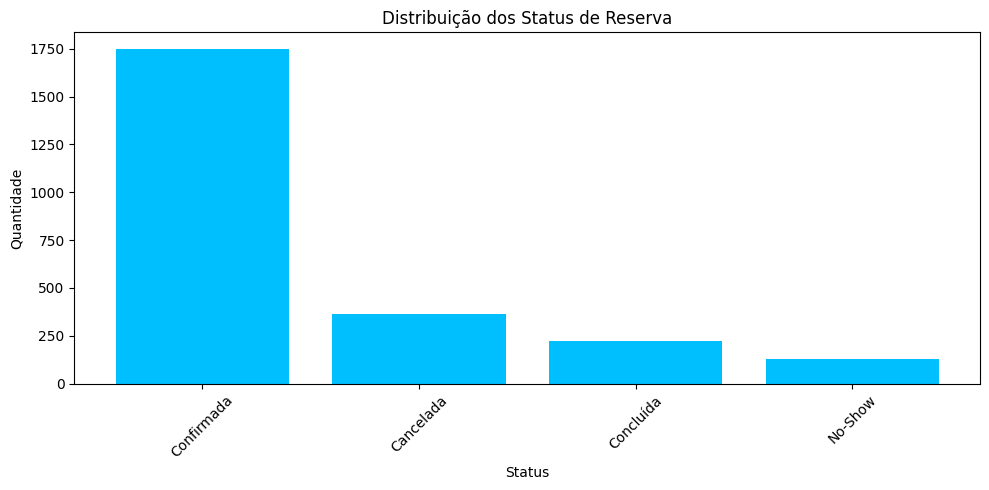

In [285]:
plt.figure(figsize=(10,5))

status_counts = df_reserva['status_reserva'].value_counts()

plt.bar(status_counts.index, status_counts.values, color='#00BFFF')

plt.title('Distribuição dos Status de Reserva')
plt.xlabel('Status')
plt.ylabel('Quantidade')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

✅ ✅ 2. GRÁFICO — FORMAS DE PAGAMENTO (comportamento do cliente)

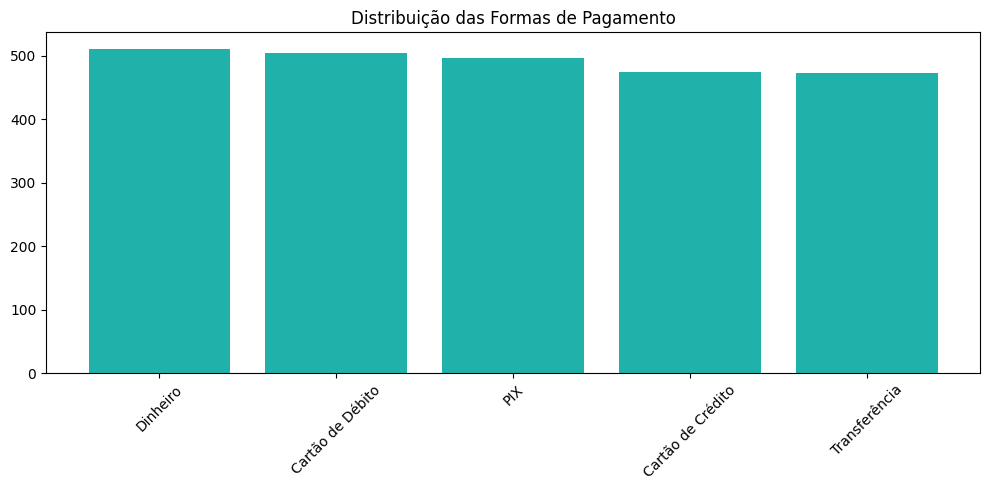

In [286]:
plt.figure(figsize=(10,5))

pagamento_counts = df_reserva['forma_pagamento'].value_counts()

plt.bar(pagamento_counts.index, pagamento_counts.values, color='#20B2AA')

plt.title('Distribuição das Formas de Pagamento')
#plt.xlabel('Forma de Pagamento')
#plt.ylabel('Quantidade')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

✅ ✅ 3. GRÁFICO — HÓSPEDES (BOXPLOT) (padrão de ocupação)

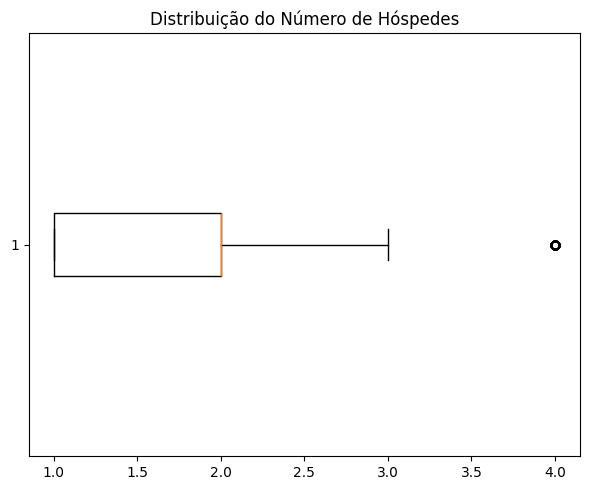

In [287]:
plt.figure(figsize=(6,5))

plt.boxplot(df_reserva['num_hospedes'],vert=False)

plt.title('Distribuição do Número de Hóspedes')

plt.tight_layout()
plt.show()

✅ ✅ 4. GRÁFICO — AVALIAÇÃO DOS CLIENTES (satisfação)

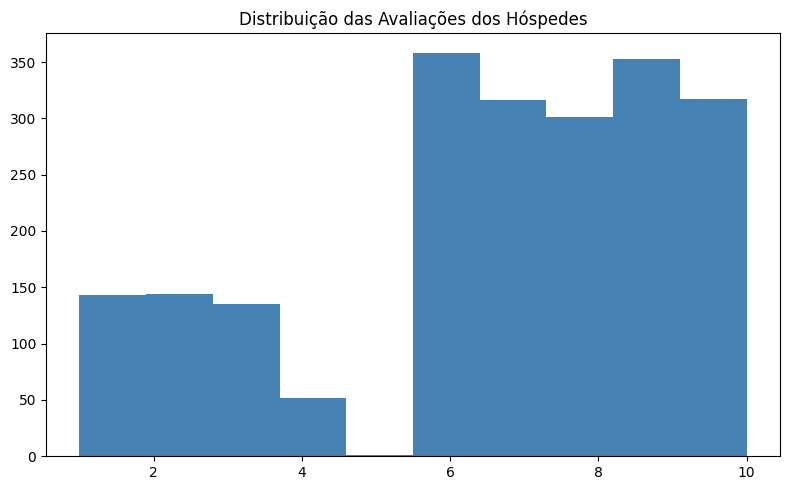

In [288]:
plt.figure(figsize=(8,5))

plt.hist(df_reserva['avaliacao_hospede'], bins=10, color='#4682B4')

plt.title('Distribuição das Avaliações dos Hóspedes')
#plt.xlabel('Avaliação')
#plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

##  `Justificativa dos Gráficos`

- O gráfico de status das reservas permite avaliar perdas operacionais, como cancelamentos e no-show  

- O gráfico de formas de pagamento evidencia o comportamento financeiro dos clientes  

- A distribuição de hóspedes permite identificar o perfil de ocupação das reservas  

- A análise das avaliações indica o nível de satisfação dos clientes  

✅ Esses indicadores foram escolhidos por sua relevância na análise operacional e estratégica da rede hoteleira
``

---
# 📊 PAINEL DE ANÁLISE

#### 
O painel a seguir reúne diferentes indicadores da base de reservas, permitindo uma visão consolidada do comportamento das reservas, perfil dos clientes e nível de satisfação.

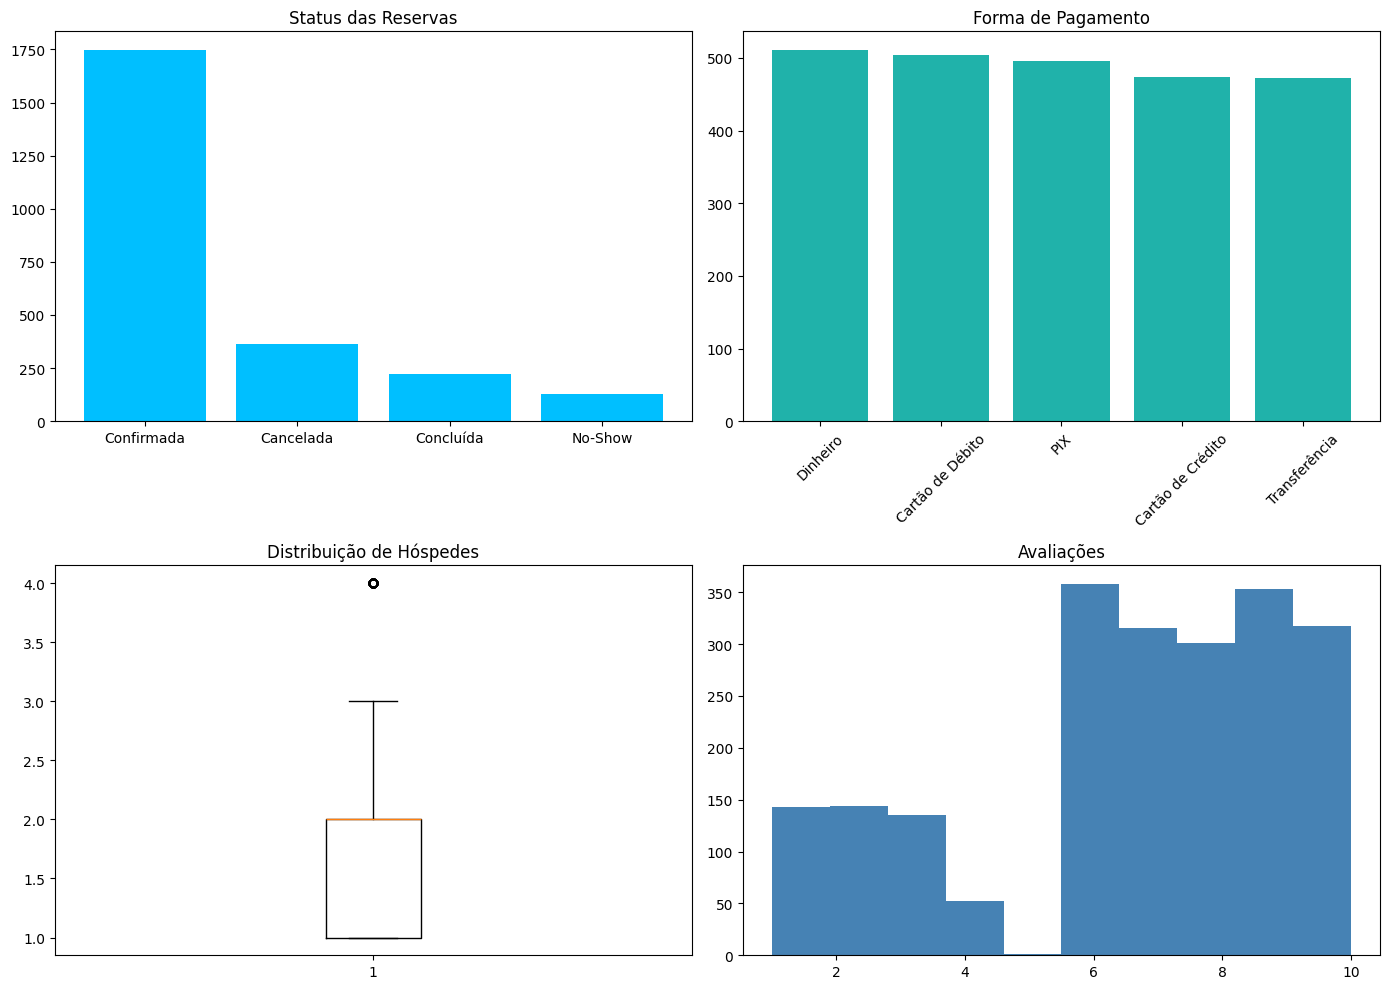

In [289]:
fig, axs = plt.subplots(2, 2, figsize=(14,10))

# --------------------------
# Status
status_counts = df_reserva['status_reserva'].value_counts()
axs[0,0].bar(status_counts.index, status_counts.values, color='#00BFFF')
axs[0,0].set_title('Status das Reservas')

# --------------------------
# Pagamento
pagamento_counts = df_reserva['forma_pagamento'].value_counts()
axs[0,1].bar(pagamento_counts.index, pagamento_counts.values, color='#20B2AA')
axs[0,1].set_title('Forma de Pagamento')
axs[0,1].tick_params(axis='x', rotation=45)

# --------------------------
# Hóspedes
axs[1,0].boxplot(df_reserva['num_hospedes'])
axs[1,0].set_title('Distribuição de Hóspedes')

# --------------------------
# Avaliações
axs[1,1].hist(df_reserva['avaliacao_hospede'], bins=10, color='#4682B4')
axs[1,1].set_title('Avaliações')

plt.tight_layout()
plt.show()

### ✅ ANÁLISE

A análise dos status das reservas mostra que há um alto volume de reservas confirmadas, porém apenas uma parte é efetivamente concluída.

Isso indica perdas operacionais relacionadas a cancelamentos e no-show, impactando diretamente a taxa real de ocupação.

Além disso, a análise das formas de pagamento mostra predominância de determinados métodos, refletindo o comportamento do cliente.

O número de hóspedes evidencia diferentes perfis de uso, enquanto as avaliações indicam o nível geral de satisfação dos clientes.



### ✅ ANÁLISE

A análise mostra que há predominância de determinados meios de pagamento, indicando preferência clara dos clientes.

Métodos como cartão e PIX tendem a concentrar maior volume, refletindo praticidade e aceitação no mercado.

Essa informação é relevante para a operação, pois diferentes formas de pagamento podem impactar custos (taxas de cartão, tempo de compensação) e estratégias comerciais.

✅ Dessa forma, compreender o comportamento dos clientes em relação ao pagamento permite otimizar processos financeiros e melhorar a experiência do cliente.


---
# 📊 ANÁLISES DE NEGÓCIO


## Análise de diárias e faturamento por unidade

#Pergunta 1: A diretoria quer entender o comportamento das diárias praticadas na rede e a distribuição do faturamento entre as unidades. O que os dados revelam?

#Importação dos dados

In [290]:
df_reservas = pd.read_csv('df_reserva_clean.csv', sep=';')
df_tipos_quarto = pd.read_csv('df_tipos_quarto_clean.csv', sep=';')
df_unidades = pd.read_csv('df_unidades_clean.csv', sep=';')

#Separando reservas válidas (que geraram receitam)

In [291]:
df_reservas_validas = df_reservas[df_reservas['status_reserva'].isin(['Confirmada','Concluída'])]
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência
5,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência


#Juntando reservas com o tipo de quarto 

In [292]:
df_reservas_valor = df_reservas_validas.merge(df_tipos_quarto, on="id_tipo_quarto")
df_reservas_valor.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,descricao,capacidade_max,valor_diaria_base
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,Standard,2,280.0
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,Standard,2,280.0
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,Suite,4,950.0
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,Standard,2,280.0
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,Deluxe,3,580.0


#Faturamento de cada reserva (valor da diária x nº de dias de hospedagem)

In [293]:
df_reservas_valor['faturamento_reserva'] = df_reservas_valor['valor_diaria_base'] * df_reservas_valor['qtd_diarias']
df_reservas_valor.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,descricao,capacidade_max,valor_diaria_base,faturamento_reserva
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,Standard,2,280.0,560.0
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,Standard,2,280.0,840.0
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,Suite,4,950.0,4750.0
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,Standard,2,280.0,1960.0
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,Deluxe,3,580.0,2900.0


#Incluindo nome da unidade na tabela de reservas_valor

In [294]:
df_reservas_valor_unidades= df_reservas_valor.merge(df_unidades, on="id_unidade")
df_reservas_valor_unidades.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,...,forma_pagamento,descricao,capacidade_max,valor_diaria_base,faturamento_reserva,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,...,Cartão de Crédito,Standard,2,280.0,560.0,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 estrelas,50
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,...,PIX,Standard,2,280.0,840.0,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 estrelas,50
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,...,Cartão de Crédito,Suite,4,950.0,4750.0,NaraHoteis Paraty,Paraty,Costa Verde,5 estrelas,65
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,...,Transferência,Standard,2,280.0,1960.0,NaraHoteis Petrópolis,Petrópolis,Serra,5 estrelas,70
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,...,Transferência,Deluxe,3,580.0,2900.0,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4 estrelas,45


#Comportamento das diárias

In [295]:
media = df_reservas_valor["valor_diaria_base"].mean()
mediana = df_reservas_valor["valor_diaria_base"].median()
variancia = df_reservas_valor["valor_diaria_base"].var()
desvio_padrao = df_reservas_valor["valor_diaria_base"].std()
coef_var = desvio_padrao / media 
distancia = (media - mediana) / mediana

print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Variância: {variancia:.2f}")
print(f"Desvio padrão: {desvio_padrao:.2f}")
print(f"Coeficiente de variação: {coef_var:.2%}")
print(f"Distância entre média e mediana: {distancia:.2%}")

Média: 555.88
Mediana: 420.00
Variância: 104132.11
Desvio padrão: 322.70
Coeficiente de variação: 58.05%
Distância entre média e mediana: 32.35%


#Faturamento por unidade NaraHoteis

In [296]:
df_faturamento_unidades = df_reservas_valor_unidades.groupby('nome_unidade')['faturamento_reserva'].sum().reset_index()
df_faturamento_unidades['percentual'] = (df_faturamento_unidades['faturamento_reserva'] / df_faturamento_unidades['faturamento_reserva'].sum()) * 100
df_faturamento_unidades

,nome_unidade,faturamento_reserva,percentual
0,NaraHoteis Angra dos Reis,368930.0,9.127164
1,NaraHoteis Barra da Tijuca,379930.0,9.399299
2,NaraHoteis Centro,161570.0,3.997170
3,NaraHoteis Friburgo,382230.0,9.456200
4,NaraHoteis Ipanema,316990.0,7.842191
5,NaraHoteis Mangaratiba,357290.0,8.839195
6,NaraHoteis Nova Iguaçu Centro,137630.0,3.404905
7,NaraHoteis Nova Iguaçu Park,375600.0,9.292177
8,NaraHoteis Paraty,415900.0,10.289181
9,NaraHoteis Petrópolis,356430.0,8.817919


In [297]:
print(df_faturamento_unidades.sort_values(by="faturamento_reserva", ascending=False))

                     nome_unidade  faturamento_reserva  percentual
8               NaraHoteis Paraty             415900.0   10.289181
10        NaraHoteis Santa Teresa             406000.0   10.044259
11         NaraHoteis Teresópolis             383610.0    9.490340
3             NaraHoteis Friburgo             382230.0    9.456200
1      NaraHoteis Barra da Tijuca             379930.0    9.399299
7     NaraHoteis Nova Iguaçu Park             375600.0    9.292177
0       NaraHoteis Angra dos Reis             368930.0    9.127164
5          NaraHoteis Mangaratiba             357290.0    8.839195
9           NaraHoteis Petrópolis             356430.0    8.817919
4              NaraHoteis Ipanema             316990.0    7.842191
2               NaraHoteis Centro             161570.0    3.997170
6   NaraHoteis Nova Iguaçu Centro             137630.0    3.404905


Conclusão

#Pergunta 1: A diretoria quer entender o comportamento das diárias praticadas na rede e a distribuição do faturamento entre as unidades. O que os
dados revelam? 

R:Os dados mostram que as diárias têm muita variação, com média em torno de R$ 560 e mediana de R$ 580, indicando preços de diárias bem diferentes entre os hotéis. O faturamento está distribuído de forma relativamente equilibrada entre as principais unidades: Paraty, Friburgo, Santa Teresa, Teresópolis e Petrópolis concentram cerca de metade da receita total, enquanto unidades como Centro e Nova Iguaçu Centro têm participação bem menor. 

## Painel Matplotlib

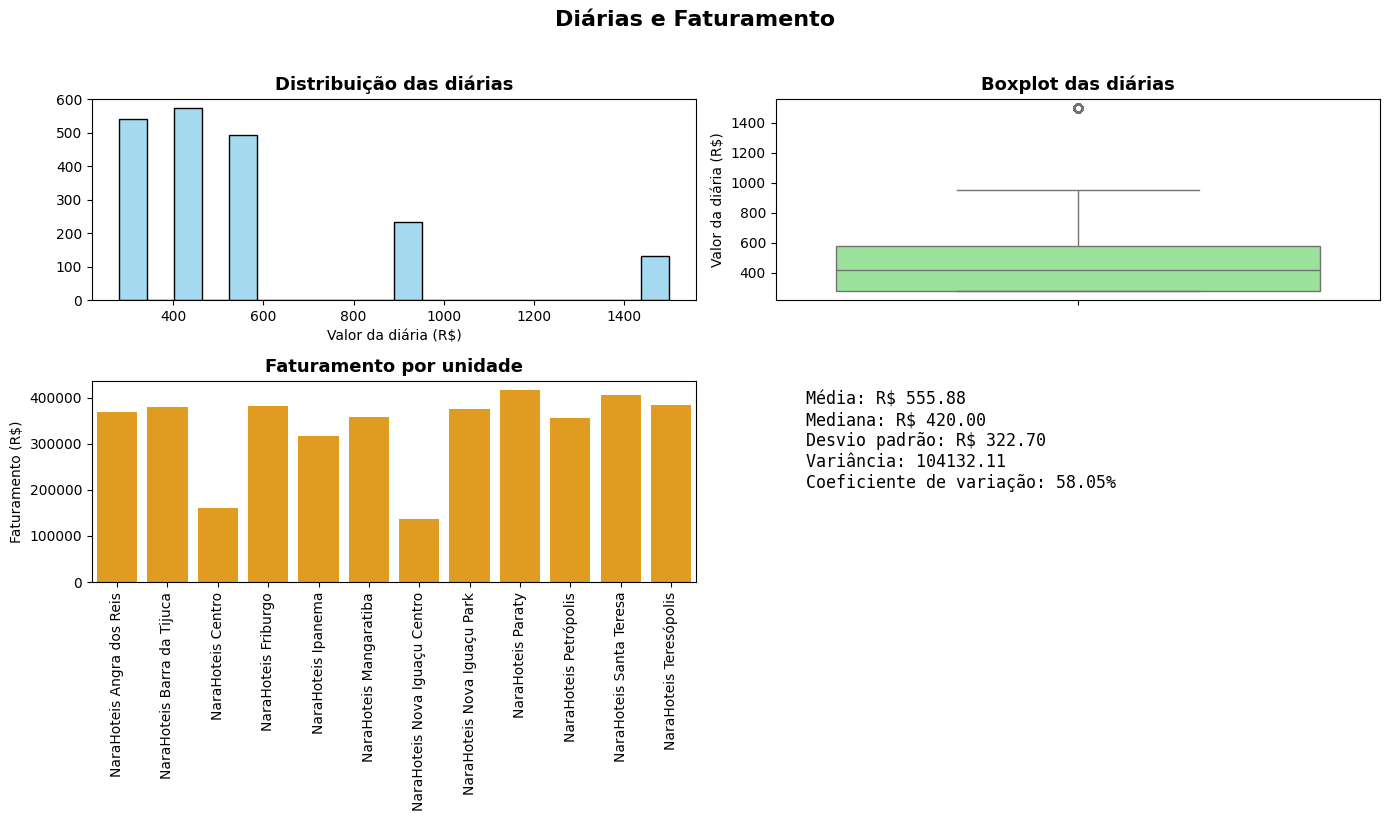

In [298]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# 1 - Histograma das diárias
sns.histplot(df_reservas_valor["valor_diaria_base"], bins=20, ax=axs[0,0], color="skyblue")
axs[0,0].set_title("Distribuição das diárias", fontsize=13, fontweight="bold")
axs[0,0].set_xlabel("Valor da diária (R$)")
axs[0,0].set_ylabel("")

# 2 - Boxplot das diárias
sns.boxplot(y=df_reservas_valor["valor_diaria_base"], ax=axs[0,1], color="lightgreen")
axs[0,1].set_title("Boxplot das diárias", fontsize=13, fontweight="bold")
axs[0,1].set_ylabel("Valor da diária (R$)")

# 3 - Faturamento por unidade (barras)
sns.barplot(x=df_faturamento_unidades["nome_unidade"], y=df_faturamento_unidades["faturamento_reserva"], ax=axs[1,0], color="orange")
axs[1,0].set_title("Faturamento por unidade", fontsize=13, fontweight="bold")
axs[1,0].set_xlabel("")
axs[1,0].set_ylabel("Faturamento (R$)")
axs[1,0].tick_params(axis="x", rotation=90)

# 4 - Métricas resumo com plt.text()
media = df_reservas_valor["valor_diaria_base"].mean()
mediana = df_reservas_valor["valor_diaria_base"].median()
desvio = df_reservas_valor["valor_diaria_base"].std()
variancia = df_reservas_valor["valor_diaria_base"].var()
coef_var = desvio / media

axs[1,1].axis("off")
texto = (
    f"Média: R$ {media:.2f}\n"
    f"Mediana: R$ {mediana:.2f}\n"
    f"Desvio padrão: R$ {desvio:.2f}\n"
    f"Variância: {variancia:.2f}\n"
    f"Coeficiente de variação: {coef_var:.2%}"
)
axs[1,1].text(0.05, 0.95, texto,
              transform=axs[1,1].transAxes,
              fontsize=12, verticalalignment="top",
              fontfamily="monospace")

# Título geral
fig.suptitle("Diárias e Faturamento", fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

Comentário:

Esse painel mostra como estão as diárias e o faturamento das unidades da rede Nara Hotéis.

O histograma ajuda a ver que os preços das diárias variam bastante.As diárias têm variação, com média em torno de R$ 560 e mediana de R$ 580, indicando preços bem diferentes entre os hotéis.

O boxplot confirma essa variação e mostra que existem alguns valores bem acima da média (outliers).

O gráfico de barras mostra o faturamento de cada unidade, deixando claro que as unidades que concentram mais faturamento são Paraty, Friburgo, Santa Teresa, Teresópolis e Petrópolis.

O quadro de métricas resume os números principais (média, mediana, desvio, variância e coeficiente de variação), facilitando a leitura do comportamento das diárias.

Com isso, dá pra concluir que as diárias têm muita diferença entre os hotéis e que o faturamento está mais concentrado em algumas unidades, como Paraty, Friburgo, Santa Teresa, Teresópolis e Petrópolis.

## Análise de unidades operando fora da capacidade 

#Pergunta 2: Existem unidades operando além de sua capacidade? Quais o impactos disso para o negócio?

#Importação dos dados

In [299]:
df_reservas = pd.read_csv( 'df_reserva_clean.csv', sep=';')
df_unidades = pd.read_csv( 'df_unidades_clean.csv' , sep=';')

#Filtrando reservas válidas

In [300]:
df_reservas_validas = df_reservas[df_reservas['status_reserva'].isin(['Confirmada','Concluída'])]
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência
5,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência


#Período das reservas

In [301]:
data_inicio_reserva = pd.to_datetime(df_reservas_validas['data_checkin']).min()
data_fim_reserva = pd.to_datetime(df_reservas_validas['data_checkout']).max()
periodo = (data_fim_reserva - data_inicio_reserva).days
print("Data início:", data_inicio_reserva)
print("Data fim:", data_fim_reserva)
print("Período em dias:", periodo)

Data início: 2023-01-01 00:00:00
Data fim: 2025-01-06 00:00:00
Período em dias: 736


#Contando o nº de reservas por dia

In [302]:
df_reservas_por_dia = df_reservas_validas.groupby(['id_unidade', 'data_checkin']).size().reset_index()
df_reservas_por_dia.columns = ['id_unidade', 'data_checkin', 'reservas_no_dia']
df_reservas_por_dia.head()

,id_unidade,data_checkin,reservas_no_dia
0,1,2023-01-05,1
1,1,2023-01-10,1
2,1,2023-01-13,1
3,1,2023-01-15,1
4,1,2023-01-23,1


#Capacidade dos hotéis: o número de quartos fazendo o merge com a tabela de unidades

In [303]:
df_capacidade_unidades = df_reservas_por_dia.merge(df_unidades[['id_unidade','nome_unidade','num_quartos_total']], on='id_unidade')
df_capacidade_unidades.head()

,id_unidade,data_checkin,reservas_no_dia,nome_unidade,num_quartos_total
0,1,2023-01-05,1,NaraHoteis Ipanema,80
1,1,2023-01-10,1,NaraHoteis Ipanema,80
2,1,2023-01-13,1,NaraHoteis Ipanema,80
3,1,2023-01-15,1,NaraHoteis Ipanema,80
4,1,2023-01-23,1,NaraHoteis Ipanema,80


#Verificando se o nº de reservas/check ins no dia é superior ao nº de quartos da unidade para identificar se há overbooking.

In [304]:
df_unidades_com_overbooking = df_capacidade_unidades[df_capacidade_unidades['reservas_no_dia'] > df_capacidade_unidades['num_quartos_total']]
df_unidades_com_overbooking.head()

,id_unidade,data_checkin,reservas_no_dia,nome_unidade,num_quartos_total
275,3,2023-07-15,74,NaraHoteis Centro,60
289,3,2024-01-15,79,NaraHoteis Centro,60
503,5,2023-10-15,62,NaraHoteis Nova Iguaçu Centro,50
528,5,2024-06-15,64,NaraHoteis Nova Iguaçu Centro,50


Conclusão

#Pergunta 2: Existem unidades operando além de sua capacidade? Quais os impactos disso para o negócio?

R:Sim, existem unidades operando além da capacidade. Encontramos 4 datas em que o número de pessoas chegando para entrar no hotel foi maior do que a quantidade de quartos que o hotel possui: o NaraHoteis Centro estourou a capacidade duas vezes (em 15/07/2023 com 74 reservas e em 15/01/2024 com 79 reservas, sendo que ele só tem 60 quartos).O NaraHoteis Nova Iguaçu Centro também estourou duas vezes (em 15/10/2023 com 62 reservas e em 15/06/2024 com 64 reservas, para um total de 50 quartos).
Impactos para o negócio são overbooking real, reembolso do valor pago pela reserva que não pode ser honrada,clientes insatisfeitos,além de sobrecarga da equipe do hotel.

## Análise de performance de receita por unidade

#Pergunta 3: Existem unidades com performance de receita discrepante em relação às demais? Como você identificaria, mediria e comprovaria isso?

#Importação dos dados

In [305]:
df_reservas = pd.read_csv("df_reserva_clean.csv", sep=";")
df_unidades = pd.read_csv("df_unidades_clean.csv", sep=";")
df_quartos = pd.read_csv("df_tipos_quarto_clean.csv", sep=";")

#Filtrando as reservas válidas

In [306]:
df_reservas_validas = df_reservas[df_reservas['status_reserva'].isin(['Confirmada','Concluída'])]
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência
5,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência


#Valor da diária pelo tipo do quarto 

In [307]:
df_reservas_validas = df_reservas_validas.merge(df_quartos[['id_tipo_quarto','valor_diaria_base','descricao']],on='id_tipo_quarto')
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,valor_diaria_base,descricao
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,280.0,Standard
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,280.0,Standard
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,950.0,Suite
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,280.0,Standard
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,580.0,Deluxe


#Receita de cada reserva


In [308]:
df_reservas_validas['receita'] = df_reservas_validas['qtd_diarias'] * df_reservas_validas['valor_diaria_base']
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,valor_diaria_base,descricao,receita
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,280.0,Standard,560.0
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,280.0,Standard,840.0
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,950.0,Suite,4750.0
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,280.0,Standard,1960.0
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,580.0,Deluxe,2900.0


#Total de receita por unidade

In [309]:
df_receita_unidade = df_reservas_validas.groupby(['id_unidade'])['receita'].sum().reset_index()
df_receita_unidade

,id_unidade,receita
0,1,316990.0
1,2,379930.0
2,3,161570.0
3,4,406000.0
4,5,137630.0
5,6,375600.0
6,7,356430.0
7,8,383610.0
8,9,382230.0
9,10,415900.0


#Total de receita por Unidade

In [310]:
df_receita_unidade = df_receita_unidade.merge(df_unidades[['id_unidade','nome_unidade',]], on='id_unidade')
df_receita_unidade.head()

,id_unidade,receita,nome_unidade
0,1,316990.0,NaraHoteis Ipanema
1,2,379930.0,NaraHoteis Barra da Tijuca
2,3,161570.0,NaraHoteis Centro
3,4,406000.0,NaraHoteis Santa Teresa
4,5,137630.0,NaraHoteis Nova Iguaçu Centro


#Verificando Outliers

In [311]:
array_df_receita_unidade=np.array(df_receita_unidade['receita'])

Q1 = np.percentile(array_df_receita_unidade, 25)
Q3 = np.percentile(array_df_receita_unidade, 75)
IQR = Q3 - Q1
limite_inferior = Q1 - (1.5 * IQR)
limite_superior = Q3 + (1.5 * IQR)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

Q1: 346570.0
Q3: 382575.0
IQR: 36005.0
Limite inferior: 292562.5
Limite superior: 436582.5


#Demarcando outliers

In [312]:
df_receita_unidade['outlier'] = (df_receita_unidade['receita'] < limite_inferior) | (df_receita_unidade['receita'] > limite_superior)
df_receita_unidade

,id_unidade,receita,nome_unidade,outlier
0,1,316990.0,NaraHoteis Ipanema,False
1,2,379930.0,NaraHoteis Barra da Tijuca,False
2,3,161570.0,NaraHoteis Centro,True
3,4,406000.0,NaraHoteis Santa Teresa,False
4,5,137630.0,NaraHoteis Nova Iguaçu Centro,True
5,6,375600.0,NaraHoteis Nova Iguaçu Park,False
6,7,356430.0,NaraHoteis Petrópolis,False
7,8,383610.0,NaraHoteis Teresópolis,False
8,9,382230.0,NaraHoteis Friburgo,False
9,10,415900.0,NaraHoteis Paraty,False


In [313]:
print(df_receita_unidade)

    id_unidade   receita                   nome_unidade  outlier
0            1  316990.0             NaraHoteis Ipanema    False
1            2  379930.0     NaraHoteis Barra da Tijuca    False
2            3  161570.0              NaraHoteis Centro     True
3            4  406000.0        NaraHoteis Santa Teresa    False
4            5  137630.0  NaraHoteis Nova Iguaçu Centro     True
5            6  375600.0    NaraHoteis Nova Iguaçu Park    False
6            7  356430.0          NaraHoteis Petrópolis    False
7            8  383610.0         NaraHoteis Teresópolis    False
8            9  382230.0            NaraHoteis Friburgo    False
9           10  415900.0              NaraHoteis Paraty    False
10          11  368930.0      NaraHoteis Angra dos Reis    False
11          12  357290.0         NaraHoteis Mangaratiba    False


Conclusão

#Pergunta 3: Existem unidades com performance de receita discrepante em relação às demais? Como você identificaria, mediria e comprovaria isso?

Sim. As unidades NaraHoteis Centro e NaraHoteis Nova Iguaçu Centro tem receita discrepante e inferior em relação às demais.Identificamos isso calculando o IQR e destacando os outliers.

## Análise entre RevPAR das unidades e a avaliação média dos hóspedes

#Pergunta 4: Há relação entre o RevPAR das unidades e a avaliação média dos hóspedes? Essa relação é forte o suficiente para sustentar uma análise
preditiva?

#Importação dos dados

In [314]:
df_reservas = pd.read_csv("df_reserva_clean.csv", sep=";")
df_unidades = pd.read_csv("df_unidades_clean.csv", sep=";")
df_quartos = pd.read_csv("df_tipos_quarto_clean.csv", sep=";")

#Filtrando apenas as reservas válidas

In [315]:
df_reservas_validas = df_reservas[df_reservas['status_reserva'].isin(['Confirmada','Concluída'])]
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência
5,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência


#Valor da diária das reservas válidas

In [316]:
df_reservas_validas = df_reservas_validas.merge(df_quartos[['id_tipo_quarto','valor_diaria_base','descricao']], on='id_tipo_quarto')
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,valor_diaria_base,descricao
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,280.0,Standard
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,280.0,Standard
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,950.0,Suite
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,280.0,Standard
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,580.0,Deluxe


#Corrigindo o valor_diaria_base para número

In [317]:
df_reservas_validas['valor_diaria_base'] = df_reservas_validas['valor_diaria_base'].astype(str)
df_reservas_validas['valor_diaria_base'] = df_reservas_validas['valor_diaria_base'].str.replace('R$','')
df_reservas_validas['valor_diaria_base'] = df_reservas_validas['valor_diaria_base'].str.replace('.','')
df_reservas_validas['valor_diaria_base'] = df_reservas_validas['valor_diaria_base'].str.replace(',','.')
df_reservas_validas['valor_diaria_base'] = df_reservas_validas['valor_diaria_base'].astype(float)
df_reservas_validas['qtd_diarias'] = pd.to_numeric(df_reservas_validas['qtd_diarias'], errors='coerce')
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,valor_diaria_base,descricao
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,2800.0,Standard
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,2800.0,Standard
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,9500.0,Suite
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,2800.0,Standard
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,5800.0,Deluxe


#Valor total de cada reserva

In [318]:
df_reservas_validas['valor_total_reserva'] = df_reservas_validas['qtd_diarias'] * df_reservas_validas['valor_diaria_base']
df_reservas_validas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,valor_diaria_base,descricao,valor_total_reserva
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,2800.0,Standard,5600.0
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,2800.0,Standard,8400.0
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,9500.0,Suite,47500.0
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,2800.0,Standard,19600.0
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,5800.0,Deluxe,29000.0


#Juntando reservas com unidades para trazer o nome_unidade

In [319]:
df_reservas = df_reservas_validas.merge(df_unidades[['id_unidade','nome_unidade']], on='id_unidade')
df_reservas.head()

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,valor_diaria_base,descricao,valor_total_reserva,nome_unidade
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito,2800.0,Standard,5600.0,NaraHoteis Nova Iguaçu Centro
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX,2800.0,Standard,8400.0,NaraHoteis Nova Iguaçu Centro
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito,9500.0,Suite,47500.0,NaraHoteis Paraty
3,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência,2800.0,Standard,19600.0,NaraHoteis Petrópolis
4,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,Confirmada,Transferência,5800.0,Deluxe,29000.0,NaraHoteis Santa Teresa


#Receita de cada unidade

In [320]:
df_receita_unidade = (df_reservas.groupby(['id_unidade','nome_unidade'])['valor_total_reserva']
                      .sum().reset_index())
df_receita_unidade = df_receita_unidade.rename(columns={'valor_total_reserva': 'receita_total'})
df_receita_unidade.head()

,id_unidade,nome_unidade,receita_total
0,1,NaraHoteis Ipanema,3169900.0
1,2,NaraHoteis Barra da Tijuca,3799300.0
2,3,NaraHoteis Centro,1615700.0
3,4,NaraHoteis Santa Teresa,4060000.0
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0


#Avaliação média por unidade

In [321]:
df_avaliacao_unidade = (
    df_reservas.groupby('nome_unidade')['avaliacao_hospede']
    .mean().reset_index(name="avaliacao_hospede_media"))
df_avaliacao_unidade

,nome_unidade,avaliacao_hospede_media
0,NaraHoteis Angra dos Reis,7.875969
1,NaraHoteis Barra da Tijuca,7.880952
2,NaraHoteis Centro,2.101852
3,NaraHoteis Friburgo,8.060606
4,NaraHoteis Ipanema,8.116667
5,NaraHoteis Mangaratiba,7.750000
6,NaraHoteis Nova Iguaçu Centro,2.104396
7,NaraHoteis Nova Iguaçu Park,7.938931
8,NaraHoteis Paraty,7.909774
9,NaraHoteis Petrópolis,7.984615


#Lado a lado: receita de cada unidade vs avaliação média dos hóspedes

In [322]:
df_unidade_linear = df_receita_unidade.merge(df_avaliacao_unidade, on='nome_unidade')
df_unidade_linear

,id_unidade,nome_unidade,receita_total,avaliacao_hospede_media
0,1,NaraHoteis Ipanema,3169900.0,8.116667
1,2,NaraHoteis Barra da Tijuca,3799300.0,7.880952
2,3,NaraHoteis Centro,1615700.0,2.101852
3,4,NaraHoteis Santa Teresa,4060000.0,8.150943
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0,2.104396
5,6,NaraHoteis Nova Iguaçu Park,3756000.0,7.938931
6,7,NaraHoteis Petrópolis,3564300.0,7.984615
7,8,NaraHoteis Teresópolis,3836100.0,8.145299
8,9,NaraHoteis Friburgo,3822300.0,8.060606
9,10,NaraHoteis Paraty,4159000.0,7.909774


In [323]:
df_receita_unidade

,id_unidade,nome_unidade,receita_total
0,1,NaraHoteis Ipanema,3169900.0
1,2,NaraHoteis Barra da Tijuca,3799300.0
2,3,NaraHoteis Centro,1615700.0
3,4,NaraHoteis Santa Teresa,4060000.0
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0
5,6,NaraHoteis Nova Iguaçu Park,3756000.0
6,7,NaraHoteis Petrópolis,3564300.0
7,8,NaraHoteis Teresópolis,3836100.0
8,9,NaraHoteis Friburgo,3822300.0
9,10,NaraHoteis Paraty,4159000.0


#Juntando com o número de quartos

In [324]:
##df_unidades = df_unidades.merge(df_unidades[['num_quartos_total', 'nome_unidade']], on='nome_unidade')
####df_unidade.head()

In [325]:
df_unidades

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 estrelas,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4 estrelas,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3 estrelas,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4 estrelas,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 estrelas,50
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3 estrelas,55
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5 estrelas,70
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4 estrelas,60
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4 estrelas,55
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5 estrelas,65


#RevPAR

In [326]:
periodo=365
df_receita_unidade['RevPAR'] = df_receita_unidade['receita_total'] / (df_unidades['num_quartos_total'] * periodo)
df_unidades.head()


,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 estrelas,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4 estrelas,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3 estrelas,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4 estrelas,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 estrelas,50


In [327]:
df_unidade_linear

,id_unidade,nome_unidade,receita_total,avaliacao_hospede_media
0,1,NaraHoteis Ipanema,3169900.0,8.116667
1,2,NaraHoteis Barra da Tijuca,3799300.0,7.880952
2,3,NaraHoteis Centro,1615700.0,2.101852
3,4,NaraHoteis Santa Teresa,4060000.0,8.150943
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0,2.104396
5,6,NaraHoteis Nova Iguaçu Park,3756000.0,7.938931
6,7,NaraHoteis Petrópolis,3564300.0,7.984615
7,8,NaraHoteis Teresópolis,3836100.0,8.145299
8,9,NaraHoteis Friburgo,3822300.0,8.060606
9,10,NaraHoteis Paraty,4159000.0,7.909774


#Covariância entre RevPAR e avaliação média dos hóspedes

In [328]:
matriz_cov_revpar_avaliacao= np.cov(df_receita_unidade['RevPAR'], df_unidade_linear['avaliacao_hospede_media'])
print(matriz_cov_revpar_avaliacao)

# Extraindo só o valor da covariância
cov_valor = matriz_cov_revpar_avaliacao[0, 1]
print(f"Covariância: {cov_valor:.2f}")

[[3123.23568149   78.99123107]
 [  78.99123107    5.25014751]]
Covariância: 78.99


#Analisando a correlação entre RevPAR e a avaliação média dos hóspedes

In [329]:
print(df_unidades.columns)

Index(['id_unidade', 'nome_unidade', 'cidade', 'regiao', 'categoria_hotel',
       'num_quartos_total'],
      dtype='str')


In [330]:
# Junta os dados que você já criou
df_unidade_revpar = df_receita_unidade.merge(
    df_unidade_linear[['nome_unidade', 'avaliacao_hospede_media']],
    on='nome_unidade'
)

# Agora sim a correlação
r = df_unidade_revpar['RevPAR'].corr(df_unidade_revpar['avaliacao_hospede_media'])

print(f"Pearson r = {r:.4f}")

#correlacao_revpar_avaliacao_media_hospedes = np.corrcoef(df_unidades['RevPAR'], df_unidades['avaliacao_hospede_media'])
#print(f"Pearson r = {correlacao_revpar_avaliacao_media_hospedes[0,1]:.4f}")

Pearson r = 0.6169


Conclusão

#Pergunta 4: Há relação entre o RevPAR das unidades e a avaliação média dos hóspedes? Essa relação é forte o suficiente para sustentar uma análise preditiva?

R: Há correlação moderada positiva entre RevPAR e avaliação média dos hóspedes (correlação = 0,62 (aprox.)). A correlação permite sustentar uma análise preditiva.

## Análise preditiva RevPAR a partir da avaliação média dos hóspedes

#Pergunta 5: Com base nos dados históricos, é possível estimar o RevPAR esperado de uma unidade a partir da sua avaliação média? Construa e avalie esse modelo. 

#Importando dados

In [331]:
#x=df_unidades[['avaliacao_hospede_media']]
#y=df_unidades['RevPAR']
x = df_unidade_revpar[['avaliacao_hospede_media']]
y = df_unidade_revpar['RevPAR']

#Modelo preditivo

In [332]:
modelo = LinearRegression()
modelo.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[15.05]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['avaliacao_hospede_media']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,41.92
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [333]:
x_extendido = pd.DataFrame({'avaliacao_hospede_media':[9, 9.2,9.5,10]})
y_tend = modelo.predict(x_extendido)

#Visualização de resultados

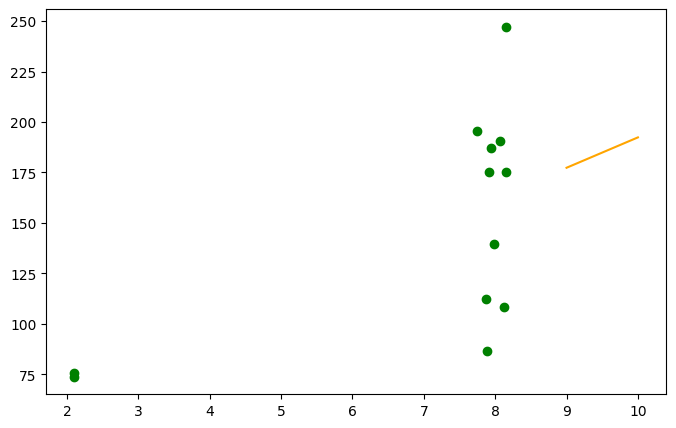

In [334]:
plt.figure(figsize=(8,5))
plt.scatter(
df_unidade_revpar['avaliacao_hospede_media'],
df_unidade_revpar['RevPAR'],
color='green',
label='Dados reais'
)
plt.plot(
x_extendido['avaliacao_hospede_media'],
y_tend,
color='orange',
label='Reta de tendência'
)

Conclusão

#Pergunta 5: Com base nos dados históricos, é possível estimar o RevPAR esperado de uma unidade a partir da sua avaliação média? Construa e avalie esse modelo.

R:Sim, é possível. Foi construído um modelo de regressão linear relacionando a avaliação média dos hóspedes com o RevPAR das unidades. O gráfico mostra uma tendência positiva: quanto maior a avaliação, maior tende a ser o RevPAR. Isso indica que a satisfação dos hóspedes tem impacto na RevPAR.

## Análise de Variabilidade de Faturamento por Região

#Pergunta 6: Qual região apresenta maior variabilidade no faturamento? O que isso pode indicar para a gestão comercial?

In [335]:
df_receita_unidade

,id_unidade,nome_unidade,receita_total,RevPAR
0,1,NaraHoteis Ipanema,3169900.0,108.558219
1,2,NaraHoteis Barra da Tijuca,3799300.0,86.742009
2,3,NaraHoteis Centro,1615700.0,73.776256
3,4,NaraHoteis Santa Teresa,4060000.0,247.184170
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0,75.413699
5,6,NaraHoteis Nova Iguaçu Park,3756000.0,187.098381
6,7,NaraHoteis Petrópolis,3564300.0,139.502935
7,8,NaraHoteis Teresópolis,3836100.0,175.164384
8,9,NaraHoteis Friburgo,3822300.0,190.400996
9,10,NaraHoteis Paraty,4159000.0,175.300316


#Exibindo a regiao das unidades e o total de receita de cada uma.

In [336]:


df_receita_regiao = df_receita_unidade.merge(df_unidades[['id_unidade','regiao']], on='id_unidade')
df_receita_regiao.head()

,id_unidade,nome_unidade,receita_total,RevPAR,regiao
0,1,NaraHoteis Ipanema,3169900.0,108.558219,Capital
1,2,NaraHoteis Barra da Tijuca,3799300.0,86.742009,Capital
2,3,NaraHoteis Centro,1615700.0,73.776256,Capital
3,4,NaraHoteis Santa Teresa,4060000.0,247.184170,Capital
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0,75.413699,Baixada Fluminense


#Analisando variabilidade por região

In [337]:
#Capital
capital = df_receita_regiao[df_receita_regiao["regiao"] == "Capital"]["receita_total"]
media_capital = np.mean(capital)
desvio_capital = np.std(capital)
print("Região: Capital")
print(f"Média da receita: {media_capital:.2f}")
print(f"Desvio padrão: {desvio_capital:.2f}")
print(f"Faixa típica: {media_capital-desvio_capital:.2f} até {media_capital+desvio_capital:.2f}\n")

#Baixada Fluminense
baixada = df_receita_regiao[df_receita_regiao["regiao"] == "Baixada Fluminense"]["receita_total"]
media_baixada = np.mean(baixada)
desvio_baixada = np.std(baixada)
print("Região: Baixada Fluminense")
print(f"Média da receita: {media_baixada:.2f}")
print(f"Desvio padrão: {desvio_baixada:.2f}")
print(f"Faixa típica: {media_baixada-desvio_baixada:.2f} até {media_baixada+desvio_baixada:.2f}\n")

#Serra
serra = df_receita_regiao[df_receita_regiao["regiao"] == "Serra"]["receita_total"]
media_serra = np.mean(serra)
desvio_serra = np.std(serra)
print("Região: Serra")
print(f"Média da receita: {media_serra:.2f}")
print(f"Desvio padrão: {desvio_serra:.2f}")
print(f"Faixa típica: {media_serra-desvio_serra:.2f} até {media_serra+desvio_serra:.2f}\n")

#Costa Verde
costa = df_receita_regiao[df_receita_regiao["regiao"] == "Costa Verde"]["receita_total"]
media_costa = np.mean(costa)
desvio_costa = np.std(costa)
print("Região: Costa Verde")
print(f"Média da receita: {media_costa:.2f}")
print(f"Desvio padrão: {desvio_costa:.2f}")
print(f"Faixa típica: {media_costa-desvio_costa:.2f} até {media_costa+desvio_costa:.2f}\n")

Região: Capital
Média da receita: 3161225.00
Desvio padrão: 949165.29
Faixa típica: 2212059.71 até 4110390.29

Região: Baixada Fluminense
Média da receita: 2566150.00
Desvio padrão: 1189850.00
Faixa típica: 1376300.00 até 3756000.00

Região: Serra
Média da receita: 3700200.00
Desvio padrão: 135900.00
Faixa típica: 3564300.00 até 3836100.00

Região: Costa Verde
Média da receita: 3807066.67
Desvio padrão: 253350.93
Faixa típica: 3553715.73 até 4060417.60



Conclusão

#Pergunta 6: Qual região apresenta maior variabilidade no faturamento? O que isso pode indicar para a gestão comercial?

A região com maior variabilidade no faturamento é a Baixada Fluminense, seguida pela Capital. Isso acontece porque as unidades dessas regiões têm receitas bem diferentes entre si. Isso indica que essas regiões são mais desiguais e precisam de mais atenção para entender o motivo dessas diferenças.

## Painel Matplotlib

In [338]:
df_receita_unidade

,id_unidade,nome_unidade,receita_total,RevPAR
0,1,NaraHoteis Ipanema,3169900.0,108.558219
1,2,NaraHoteis Barra da Tijuca,3799300.0,86.742009
2,3,NaraHoteis Centro,1615700.0,73.776256
3,4,NaraHoteis Santa Teresa,4060000.0,247.184170
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0,75.413699
5,6,NaraHoteis Nova Iguaçu Park,3756000.0,187.098381
6,7,NaraHoteis Petrópolis,3564300.0,139.502935
7,8,NaraHoteis Teresópolis,3836100.0,175.164384
8,9,NaraHoteis Friburgo,3822300.0,190.400996
9,10,NaraHoteis Paraty,4159000.0,175.300316


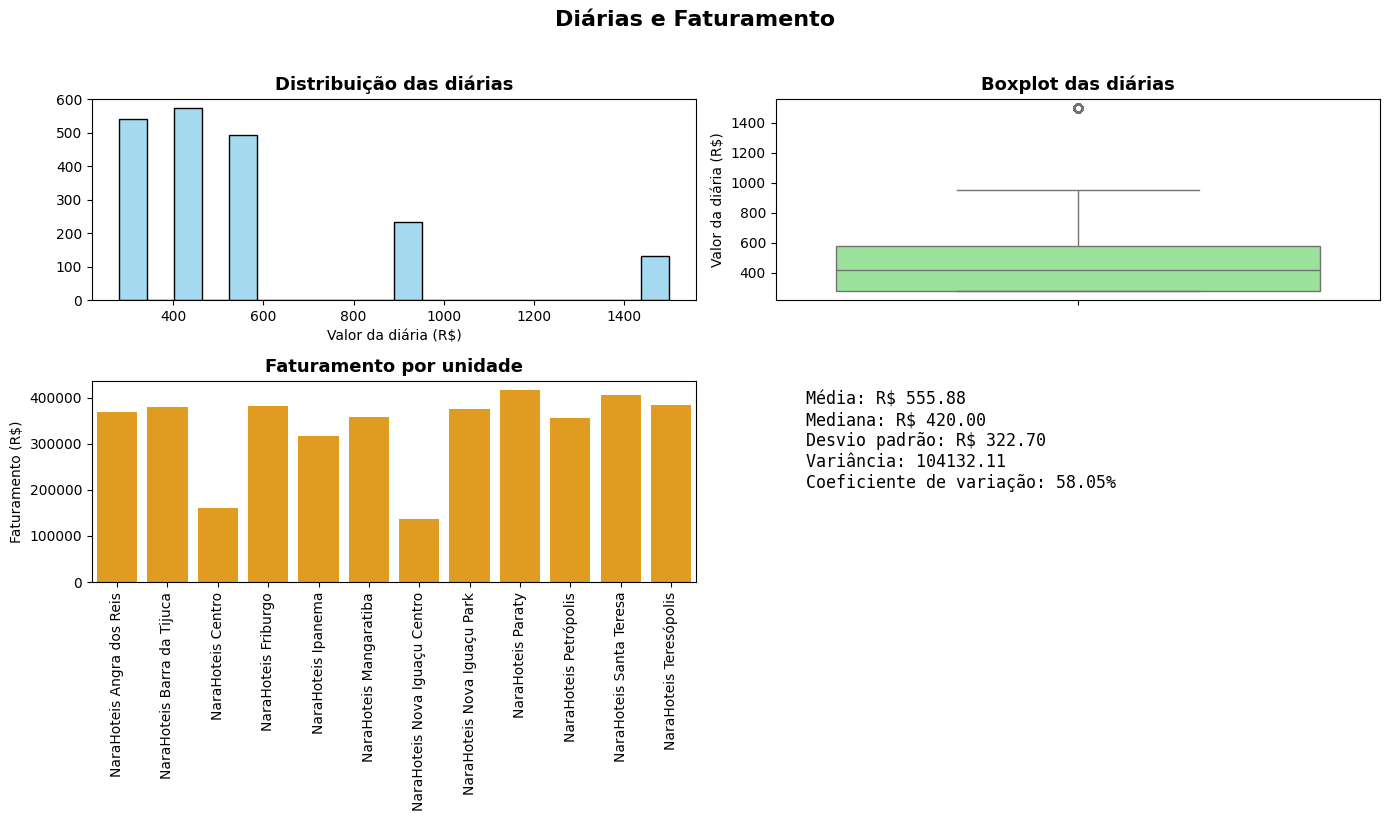

In [339]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# 1 - Histograma das diárias
sns.histplot(df_reservas_valor["valor_diaria_base"], bins=20, ax=axs[0,0], color="skyblue")
axs[0,0].set_title("Distribuição das diárias", fontsize=13, fontweight="bold")
axs[0,0].set_xlabel("Valor da diária (R$)")
axs[0,0].set_ylabel("")

# 2 - Boxplot das diárias
sns.boxplot(y=df_reservas_valor["valor_diaria_base"], ax=axs[0,1], color="lightgreen")
axs[0,1].set_title("Boxplot das diárias", fontsize=13, fontweight="bold")
axs[0,1].set_ylabel("Valor da diária (R$)")

# 3 - Faturamento por unidade (barras)
sns.barplot(x="nome_unidade", y="faturamento_reserva", data=df_faturamento_unidades, ax=axs[1,0], color="orange")
axs[1,0].set_title("Faturamento por unidade", fontsize=13, fontweight="bold")
axs[1,0].set_xlabel("")
axs[1,0].set_ylabel("Faturamento (R$)")
axs[1,0].tick_params(axis="x", rotation=90)

# 4 - Métricas resumo com plt.text()
media = df_reservas_valor["valor_diaria_base"].mean()
mediana = df_reservas_valor["valor_diaria_base"].median()
desvio = df_reservas_valor["valor_diaria_base"].std()
variancia = df_reservas_valor["valor_diaria_base"].var()
coef_var = desvio / media

axs[1,1].axis("off")
texto = (
    f"Média: R$ {media:.2f}\n"
    f"Mediana: R$ {mediana:.2f}\n"
    f"Desvio padrão: R$ {desvio:.2f}\n"
    f"Variância: {variancia:.2f}\n"
    f"Coeficiente de variação: {coef_var:.2%}"
)
axs[1,1].text(0.05, 0.95, texto,
              transform=axs[1,1].transAxes,
              fontsize=12, verticalalignment="top",
              fontfamily="monospace")

# Título geral
fig.suptitle("Diárias e Faturamento", fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

In [340]:
df_receita_unidade

,id_unidade,nome_unidade,receita_total,RevPAR
0,1,NaraHoteis Ipanema,3169900.0,108.558219
1,2,NaraHoteis Barra da Tijuca,3799300.0,86.742009
2,3,NaraHoteis Centro,1615700.0,73.776256
3,4,NaraHoteis Santa Teresa,4060000.0,247.184170
4,5,NaraHoteis Nova Iguaçu Centro,1376300.0,75.413699
5,6,NaraHoteis Nova Iguaçu Park,3756000.0,187.098381
6,7,NaraHoteis Petrópolis,3564300.0,139.502935
7,8,NaraHoteis Teresópolis,3836100.0,175.164384
8,9,NaraHoteis Friburgo,3822300.0,190.400996
9,10,NaraHoteis Paraty,4159000.0,175.300316


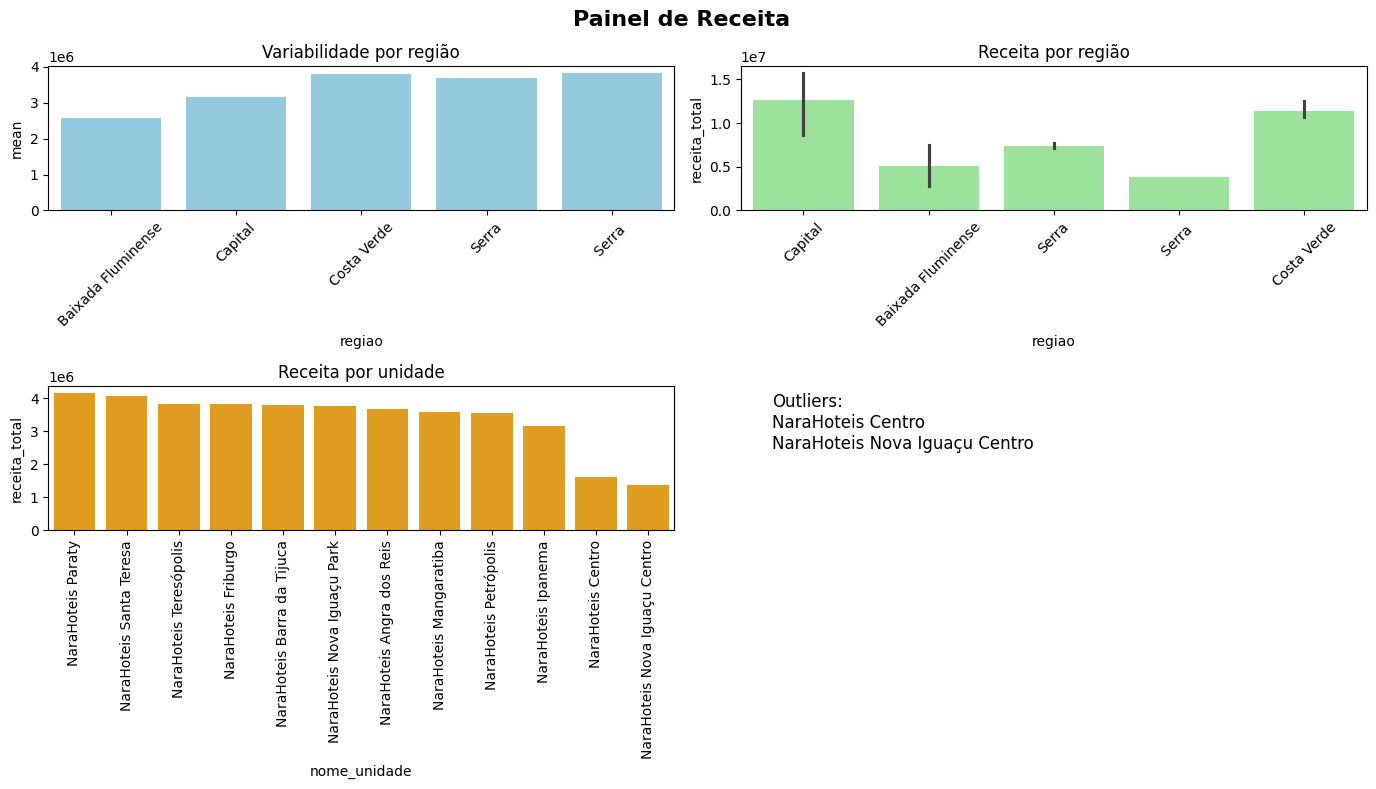

In [341]:
array = np.array(df_receita_unidade['receita_total'])

Q1 = np.percentile(array, 25)
Q3 = np.percentile(array, 75)
IQR = Q3 - Q1

limite_inferior = Q1 - (1.5 * IQR)
limite_superior = Q3 + (1.5 * IQR)

df_receita_unidade['outlier'] = (
    (df_receita_unidade['receita_total'] < limite_inferior) |
    (df_receita_unidade['receita_total'] > limite_superior)
)




fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Variabilidade por região
df_stats_regiao = df_receita_regiao.groupby("regiao")["receita_total"].agg(["mean","std"]).reset_index()

sns.barplot(
    x="regiao", y="mean",
    data=df_stats_regiao,
    ax=axs[0,0],
    color="skyblue"
)

axs[0,0].set_title("Variabilidade por região")
axs[0,0].tick_params(axis="x", rotation=45)

# Receita por região
sns.barplot(
    x="regiao", y="receita_total",
    data=df_receita_regiao,
    ax=axs[0,1],
    color="lightgreen",
    estimator=sum
)

axs[0,1].set_title("Receita por região")
axs[0,1].tick_params(axis="x", rotation=45)

# Receita por unidade
df_ord = df_receita_unidade.sort_values("receita_total", ascending=False)

sns.barplot(
    x="nome_unidade", y="receita_total",
    data=df_ord,
    ax=axs[1,0],
    color="orange"
)

axs[1,0].set_title("Receita por unidade")
axs[1,0].tick_params(axis="x", rotation=90)

# Texto (outliers)
axs[1,1].axis("off")

outliers = df_receita_unidade[
    df_receita_unidade["outlier"] == True
]["nome_unidade"].tolist()


texto = "Outliers:\n" + "\n".join(outliers)

axs[1,1].text(
    0.05, 0.95,
    texto,
    transform=axs[1,1].transAxes,
    fontsize=12,
    verticalalignment='top'
)

# Título geral
fig.suptitle("Painel de Receita", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()




Comentário:

Gráfico 1 — Variabilidade da receita por região:
Esse gráfico mostra que algumas regiões têm muita variação na receita. A região com maior variabilidade no faturamento é a Baixada Fluminense, seguida pela Capital, pois as unidades têm receitas muito diferentes entre si.

Gráfico 2 — Receita total por região:
Neste gráfico é possível identificar as regiões com maior faturamento (Costa Verde,Serra e Capital) e que são importantes para o desempenho da empresa.

Gráfico 3 — Receita por unidade:
Esse gráfico mostra quanto cada unidade gera de faturamento. Dá pra perceber que algumas unidades têm um faturamento bem menor que outras (Centro e Nova Iguaçú Centro), o que mostra diferença de desempenho entre elas.

Gráfico 4 — Outliers:
Nesse quadro destacamos as unidades que estão fora do padrão. Ou seja, unidades que têm receita muito diferente das outras.As unidades NaraHoteis Centro e NaraHoteis Nova Iguaçu Centro tem receita discrepante e inferior em relação às demais.

Conclusão:
No geral, o painel ajuda a entender como está a receita da empresa, mostrando diferenças entre regiões e unidades. Isso ajuda a identificar onde estão os melhores resultados e pontos de melhoria.

---
#